# Trend class prediction on binned time series

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import pyreadr
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
import numpy as np
import optuna
import shap
import statsmodels.formula.api as smf

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import LinearRegressionModel

from itertools import product

from lightgbm import LGBMClassifier

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from scipy import stats
from scipy.stats import f_oneway

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score, mean_absolute_error, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from statsmodels.stats.multicomp import pairwise_tukeyhsd

from tsfresh import extract_features

The StatsForecast module could not be imported. To enable support for the StatsForecastAutoARIMA, StatsForecastAutoETS and Croston models, please consider installing it.


## ERA5 data

In [2]:
# get era5 data

era = pyreadr.read_r('../Data/era5_met.rds')[None]
era['date'] = pd.to_datetime(era['date'])
era['year'] = era['date'].dt.year
era['month'] = era['date'].dt.month

In [3]:
era

,station_id,date,tair,tp,sf,year,month
0,3_1,1960-01-01,270.935638,1.024788e-02,1.024122e-02,1960,1
1,3_1,1960-01-02,268.549255,8.457695e-03,8.453619e-03,1960,1
2,3_1,1960-01-03,265.638245,1.111615e-06,5.234033e-07,1960,1
3,3_1,1960-01-04,264.218536,1.451688e-05,1.340872e-05,1960,1
4,3_1,1960-01-05,265.721497,9.060125e-04,9.025466e-04,1960,1
...,...,...,...,...,...,...,...
28246037,1177_1,2024-06-26,287.689789,2.659548e-04,0.000000e+00,2024,6
28246038,1177_1,2024-06-27,285.414764,1.099903e-03,0.000000e+00,2024,6
28246039,1177_1,2024-06-28,284.358337,4.007968e-03,1.303852e-08,2024,6
28246040,1177_1,2024-06-29,286.996796,7.222891e-05,0.000000e+00,2024,6


In [4]:
lakes = pyreadr.read_r('../Data/ltbl_ice.rds')[None]
fs_lakes = set(lakes.loc[lakes['lon_wgs84'] > 0, 'station_id'].unique())
fin_lakes = set(lakes.loc[lakes['country'] == 'FI', 'station_id'].unique())

In [5]:
# Could filter to FS lakes
# era = era.loc[era['station_id'].isin(fs_lakes), :]

## Ice data

In [6]:
ice = pyreadr.read_r('../Data/data_ip.rds')[None]

ice['ice_on'] = pd.to_datetime(ice['ice_on'])
ice['ice_off'] = pd.to_datetime(ice['ice_off'])
ice['year'] = ice['year'].astype(int)

# keep fs lakes
# ice = ice.loc[ice['station_id'].isin(fs_lakes), :]

# keep where ice on not null
ice = ice[ice[['ice_on']].notnull().all(axis=1)]

# cut to same dates as in era and subset to same stations
ice = ice.loc[ice['ice_on'] >= era['date'].min(), :]
ice = ice.loc[ice['ice_off'] <= era['date'].max(), :]

/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)
/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


In [7]:
ice.dtypes

station_id            object
year                   int64
ice_on        datetime64[ns]
ice_off       datetime64[ns]
dtype: object

### Group all time series into 4 period bins by year and keep complete only

In [8]:
bins = pd.interval_range(start=ice['year'].min(), end=ice['year'].max(),
                         periods=4)
bins

IntervalIndex([(1960, 1976], (1976, 1992], (1992, 2008], (2008, 2024]], dtype='interval[int64, right]')

In [9]:
ice['bin'] = pd.cut(ice['year'], bins)
ice

,station_id,year,ice_on,ice_off,bin
11,3_1,1961,1960-11-01,1961-05-30,"(1960, 1976]"
12,3_1,1962,1961-11-28,1962-05-30,"(1960, 1976]"
13,3_1,1963,1962-11-18,1963-05-24,"(1960, 1976]"
14,3_1,1964,1963-11-12,1964-05-30,"(1960, 1976]"
15,3_1,1965,1964-11-09,1965-06-02,"(1960, 1976]"
...,...,...,...,...,...
37319,1196_1,2020,2019-11-12,2020-03-12,"(2008, 2024]"
37320,1196_1,2021,2020-12-06,2021-03-20,"(2008, 2024]"
37321,1196_1,2022,2021-12-07,2022-03-25,"(2008, 2024]"
37322,1196_1,2023,2022-11-21,2023-03-20,"(2008, 2024]"


In [10]:
def is_complete(_bin, group):
    # assume right interval
    years_in_group = set(group['year'].unique())
    years_in_bin = set(range(_bin.left+1, _bin.right+1))

    # same years in bin and group
    return len(years_in_bin.difference(years_in_group)) == 0

In [11]:
gb = ice.groupby(['bin', 'station_id'])

n_complete = {}
complete_groups = []

for idx, (group_id, group_df) in enumerate(gb):
    _bin = group_df['bin'].iloc[0]
    
    if is_complete(_bin, group_df):
        complete_groups.append(group_df)
        try:
            n_complete[_bin] += 1
        except KeyError:
            n_complete[_bin] = 1
        
print(n_complete)

{Interval(1960, 1976, closed='right'): 264, Interval(1976, 1992, closed='right'): 236, Interval(1992, 2008, closed='right'): 88, Interval(2008, 2024, closed='right'): 38}


In [12]:
ice = pd.concat(complete_groups)
ice.dtypes

station_id            object
year                   int64
ice_on        datetime64[ns]
ice_off       datetime64[ns]
bin                 category
dtype: object

In [13]:
# n station ids by bins (same as above)
ice.groupby(['bin'])['station_id'].nunique()

bin
(1960, 1976]    264
(1976, 1992]    236
(1992, 2008]     88
(2008, 2024]     38
Name: station_id, dtype: int64

In [14]:
ice.groupby(['bin'])['station_id'].nunique().sum()

626

In [15]:
ice['station_id'].nunique()

403

#### Plot ice on month distributions

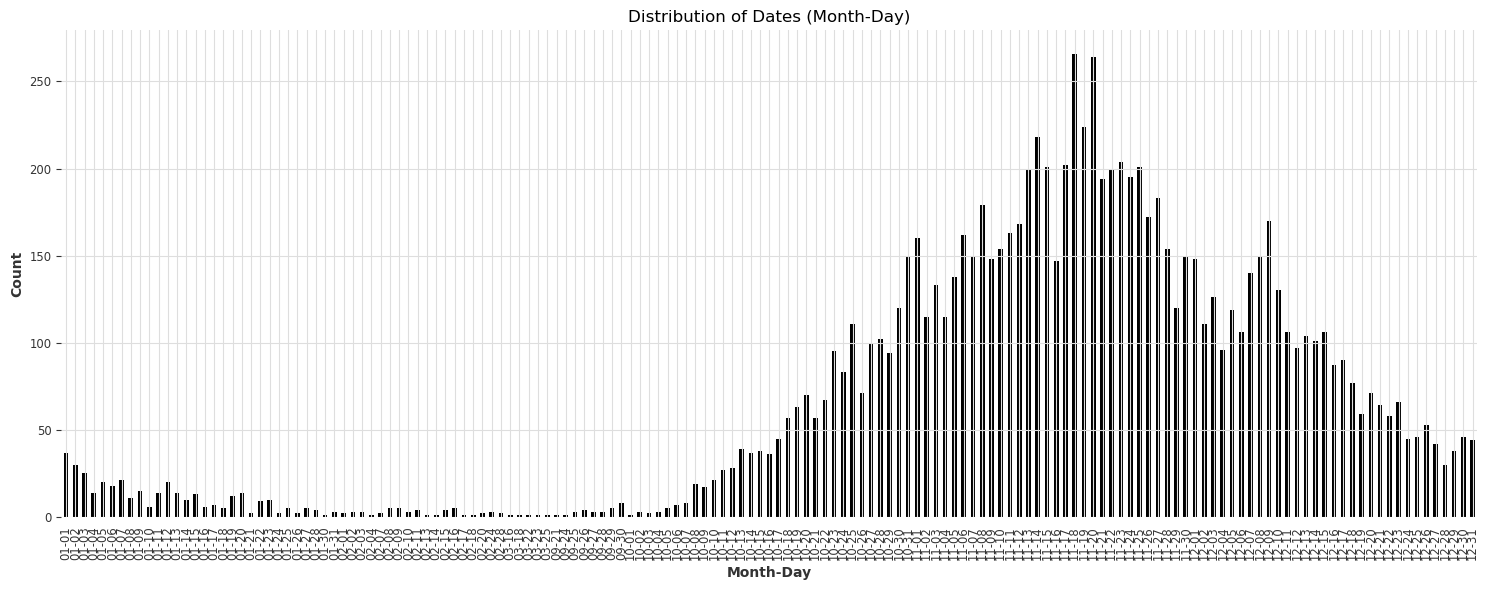

In [16]:
# What's the earliest ice_on?
month_days = ice['ice_on'].dt.strftime('%m-%d').value_counts().sort_index()

plt.figure(figsize=(15, 6))
month_days.plot(kind='bar')
plt.title('Distribution of Dates (Month-Day)')
plt.xlabel('Month-Day')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

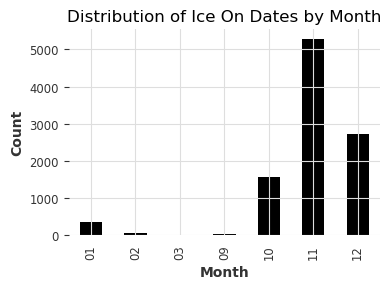

In [17]:
# By month

month_counts = ice['ice_on'].dt.strftime('%m').value_counts().sort_index()

plt.figure(figsize=(4, 3))
month_counts.plot(kind='bar')
plt.title('Distribution of Ice On Dates by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../Images/ice-on-distr.png', dpi=600)
plt.show()

Data in the Northern hemisphere, calculate distance to 1st of January this year if ice on before July, to 1st Jan next year if after July.

In [18]:
before_july = ice['ice_on'].dt.month < 7

ice['jan_1_current_year'] = pd.to_datetime(ice['ice_on'].dt.year.astype(str) + '-01-01')
ice['jan_1_next_year'] = pd.to_datetime((ice['ice_on'].dt.year + 1).astype(str) + '-01-01')

ice['distance_to_jan_1'] = np.where(
    before_july,
    (ice['jan_1_current_year'] - ice['ice_on']).dt.days,  # negative
    (ice['jan_1_next_year'] - ice['ice_on']).dt.days      # positive
)

# Drop intermediate columns
ice.drop(columns=['jan_1_current_year', 'jan_1_next_year'], inplace=True)

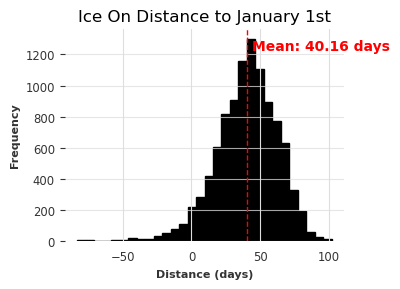

In [19]:
plt.figure(figsize=(4, 3))
plt.hist(ice['distance_to_jan_1'], bins=30, edgecolor='black')

# Customize the plot
plt.title('Ice On Distance to January 1st', fontsize=12)
plt.xlabel('Distance (days)', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.grid(axis='y', alpha=0.75)

# Add mean line
mean_distance = ice['distance_to_jan_1'].mean()
plt.axvline(mean_distance, color='red', linestyle='dashed', linewidth=1)
plt.text(mean_distance*1.1, plt.ylim()[1]*0.9, f'Mean: {mean_distance:.2f} days', 
         color='red', fontweight='bold')

# Show the plot
plt.tight_layout()
plt.savefig('../Images/ice-on-jan1-dist-distr.png', dpi=600)
plt.show()

#### Plot time series of `distance_to_jan_1` by bins, fit OLS

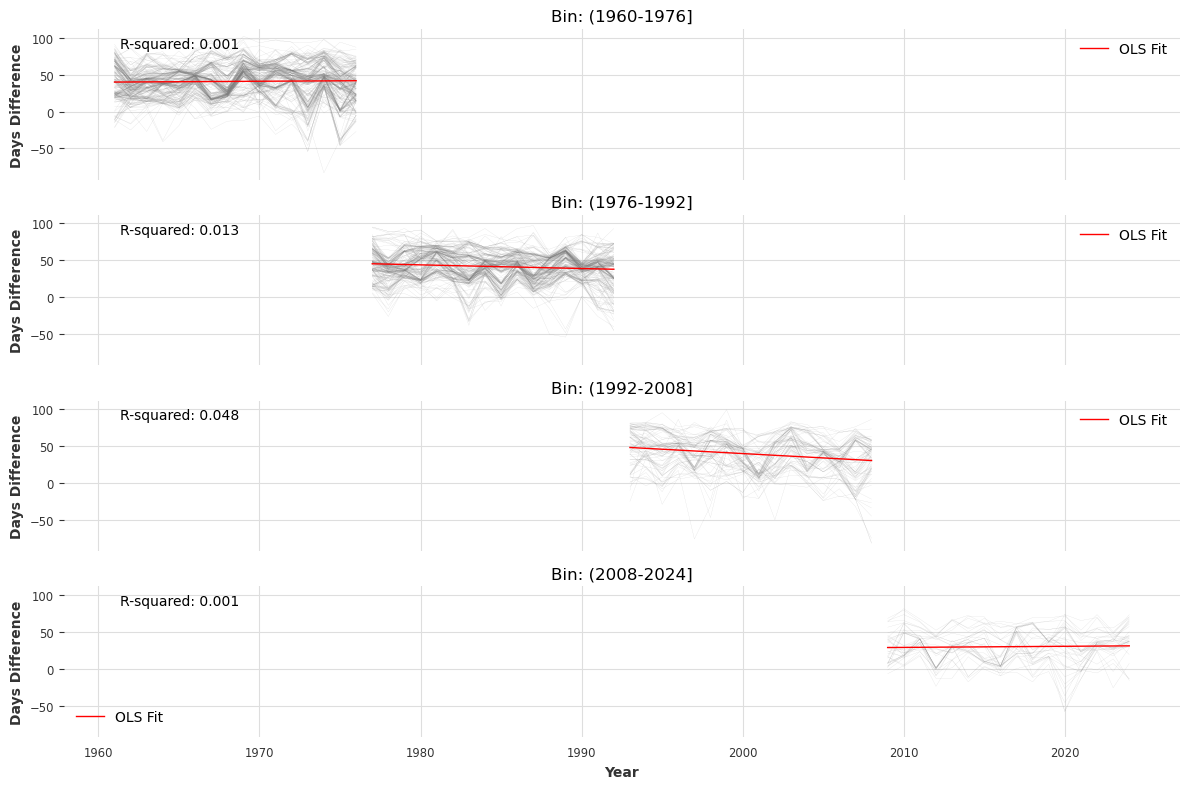

In [20]:
import statsmodels.api as sm

fig, axes = plt.subplots(len(bins), 1, figsize=(12, 8), sharex=True, sharey=True)

for i, bin_interval in enumerate(bins):
    ax = axes[i]
    bin_df = ice[ice['bin'] == bin_interval]
    
    for station_id in bin_df['station_id'].unique():
        station_df = bin_df[bin_df['station_id'] == station_id]
        
        # plot station data
        ax.plot(station_df['year'], station_df['distance_to_jan_1'], 
                label='', color='gray', alpha=0.5, linewidth=0.1)

    # Make and plot OLS model
    
    # Prepare data for regression
    X = bin_df['year'].values 
    y = bin_df['distance_to_jan_1'].values
    
    # Add constant (and squared if needed) term for polynomial regression
    # X = sm.add_constant(np.column_stack((X, X**2)))
    X = sm.add_constant(X)
    
    # Fit the model
    model = sm.OLS(y, X).fit()
    
    # Generate predictions
    x_smooth = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    # X_pred = sm.add_constant(np.column_stack((x_smooth, x_smooth**2)))
    X_pred = sm.add_constant(x_smooth)
    y_pred = model.predict(X_pred)

    ax.plot(x_smooth, y_pred, color='red', linewidth=1, 
            label='OLS Fit')

    # Add R-squared value to the plot
    ax.text(0.05, 0.95, f'R-squared: {model.rsquared:.3f}', 
            transform=ax.transAxes, 
            verticalalignment='top')

    
    ax.set_title(f'Bin: ({bin_interval.left}-{bin_interval.right}]')
    ax.set_ylabel('Days Difference')
    ax.legend()

plt.xlabel('Year')
plt.tight_layout()
plt.savefig('../Images/jan1-dist-binned-overview.png', dpi=600)


### Box-plots on `distance_to_jan_1`

In [21]:
# Group data by bins
box_data = [ice[ice['bin'] == bin_interval]['distance_to_jan_1'] for bin_interval in bins]

# Perform one-way ANOVA
f_stat, p_value = f_oneway(*box_data)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value < 0.05:
    # Create a DataFrame for Tukey's HSD
    tukey_data = pd.DataFrame({
        'distance_to_jan_1': ice['distance_to_jan_1'],
        'bin': ice['bin'].apply(lambda x: f'{x.left}-{x.right}')
    })
    
    tukey_result = pairwise_tukeyhsd(tukey_data['distance_to_jan_1'], tukey_data['bin'])
    print(tukey_result)

    # Extract group labels from Tukey's HSD results
    group_labels = {group: label for group, label in zip(tukey_result.groupsunique, tukey_result._results_table.data[1:])}
else:
    print("No significant differences found between groups.")
    group_labels = {f'{bin_interval.left}-{bin_interval.right}': 'a' for bin_interval in bins}



ANOVA F-statistic: 55.99, p-value: 0.0000
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
1960-1976 1976-1992   0.7638 0.3898  -0.4779  2.0055  False
1960-1976 1992-2008  -1.6982 0.0516  -3.4043   0.008  False
1960-1976 2008-2024 -11.1742    0.0 -13.5792 -8.7692   True
1976-1992 1992-2008  -2.4619 0.0015  -4.1933 -0.7306   True
1976-1992 2008-2024  -11.938    0.0 -14.3608 -9.5151   True
1992-2008 2008-2024   -9.476    0.0 -12.1667 -6.7854   True
-----------------------------------------------------------


In [22]:
# https://github.com/timyerg/cld4py/blob/main/cld4py/cld4py.py
import string

def assign_letters(df, G1, G2, P, alpha=.05,
           order=None, data=None, vals=None, group=None, param=True):
    """
    Function to apply compact letter display for pairwise contrasts.
    Groups with no significant differences share a letter.
    
    Parameters:
    
      Required:
        df    - dataframe with contrasts (pairwise comparisons).
        G1, G2 - columns in contrasts df with compared groups.
        P      - column in contrasts df with p-value (adjusted, right?).
        
      Optional:
        alpha  - sigificance level (default 0.05).
        order  - None (default), list or ['ascending', 'descending'].
                 This parameter will define the order of assigned letters.
                 None - alphabetical order will be applied.
                 List - order of groups will be defined by that list.
                 String 'ascending' or 'descending' requires parameters
                 'data', 'values' and 'group' to order groups by the mean.
        data   - dataframe with values that were compared to get contrasts.
        vals   - column in data with compared values.
        group  - column in data with group information.
        param  - wether sort by mean (True; default) or median (False).
    """
    
    #helper function to check p
    def is_sign(lv1, lv2, df=df, alpha=alpha):
        return df.loc[(df[G1]==lv1)&(df[G2]==lv2)|(df[G1]==lv2)&(df[G2]==lv1),P].iloc[0] < alpha
          
    letters = string.ascii_lowercase
    df[P] = df[P].apply(pd.to_numeric)
    
    #define order
    if order == None:
        order = sorted(set(df[G1].tolist() + df[G2].tolist()))
    if order in ['ascending', 'descending']:
        asc = order=='ascending'
        data[vals] = data[vals].apply(pd.to_numeric)
        if param:
            order = pd.DataFrame(data.groupby(group)[vals].mean()).sort_values(vals, ascending=asc).index.tolist()
        else:
            order = pd.DataFrame(data.groupby(group)[vals].median()).sort_values(vals, ascending=asc).index.tolist()
    #assign letters
    draft, sets = {}, []
    for i, l1 in enumerate(order):
        draft.update({i: {l1}})
        for l2 in order: 
            if l1 != l2 and not any([is_sign(l1,l2)]+[is_sign(l,l2) for l in draft[i]]):
                    draft[i].add(l2)
    [sets.append(v) for v in draft.values() if v not in sets]
    cld = pd.DataFrame(columns=['Group', 'Letters'])
    for i,l in enumerate(order):
        cld.loc[i, ['Group', 'Letters']] = l, ''.join([letters[j] for j,s in enumerate(sets) if l in s])
    return cld.set_index('Group')

In [23]:
df = pd.DataFrame(tukey_result._results_table.data)
df.columns = df.iloc[0]
df = df.drop(df.index[0])

group_labels = assign_letters(df, 'group1', 'group2', 'p-adj').to_dict()['Letters']

In [24]:
# Check that the generated labels are OK

def validate_labels(group_labels, tukey_results):
    df = pd.DataFrame(tukey_result._results_table.data)
    df.columns = df.iloc[0]
    df = df.drop(df.index[0])
    # print(df)
    
    groups = list(group_labels.keys())
    
    for g1, g2 in zip(groups[:-1], groups[1:]):
        rej = df.loc[(df['group1'] == g1) & (df['group2'] == g2), 'reject'].values[0]

        if rej == True:
            # Should be no shared letters.
            assert len(set(group_labels[g1]).intersection(set(group_labels[g2]))) == 0

validate_labels(group_labels, tukey_result)
        

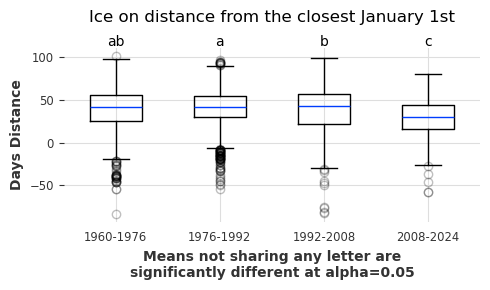

In [25]:
# Plot box plots with significance labels

fig, ax = plt.subplots(figsize=(5, 3))

positions = range(1, len(bins) + 1)

box_plot = ax.boxplot(box_data, positions=positions, widths=0.5)

for flier in box_plot['fliers']:
    flier.set(marker='o', 
              markerfacecolor='none',
              markeredgecolor='black', 
              alpha=0.25,
              markersize=6)

# Set x-tick labels to bin ranges
ax.set_xticks(positions)
ax.set_xticklabels([f'{bin_interval.left}-{bin_interval.right}' for bin_interval in bins])

# Add significance labels above each box plot
for i, bin_interval in enumerate(bins):
    label = group_labels.get(f'{bin_interval.left}-{bin_interval.right}', 'NA')
    ax.text(positions[i], 110, # max(box_data) + 0.5
            label,
            horizontalalignment='center', verticalalignment='bottom')

ax.set_xlabel('Means not sharing any letter are\nsignificantly different at alpha=0.05')
ax.set_ylabel('Days Distance')
ax.set_title('Ice on distance from the closest January 1st\n')

plt.tight_layout()
plt.savefig('../Images/jan1-dist-anova-tukey.png', dpi=600)
plt.show()


In [26]:
ice.dtypes

station_id                   object
year                          int64
ice_on               datetime64[ns]
ice_off              datetime64[ns]
bin                        category
distance_to_jan_1             int64
dtype: object

#### Group by station and year bin, build time series

In [27]:
grouped = ice.groupby(['station_id', 'bin'])

time_series_dict = {}
for (station_id, bin_label), group in grouped:
    ts = TimeSeries.from_dataframe(
        group,
        time_col='year',
        value_cols='distance_to_jan_1',
    )
    time_series_dict[(station_id, bin_label)] = ts


In [28]:
len(list(time_series_dict.keys()))

626

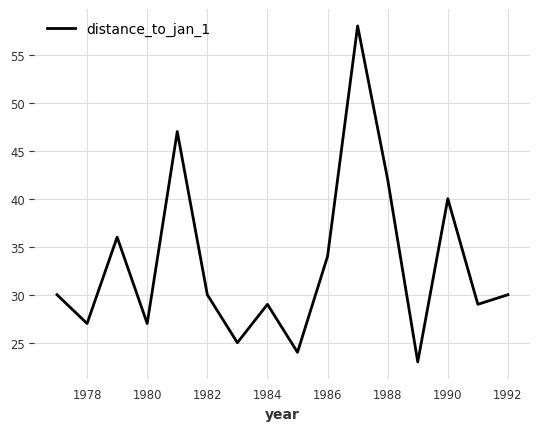

In [29]:
# Plot one
time_series_dict[list(time_series_dict.keys())[0]].plot();

#### We can run, e.g., second order OLS or some more complicated model

In [30]:
lin_terms = []
quad_terms = []
keys = []

for key, ts in time_series_dict.items():
    keys.append(key)

    x = ts.time_index.values
    y = ts.values().flatten()

    data = pd.DataFrame({'x': x, 'y': y})
    model = smf.ols(formula='y ~ x + I(x**2)', data=data).fit()
    linear_term = model.params['x']
    quadratic_term = model.params['I(x ** 2)']

    lin_terms.append(linear_term)
    quad_terms.append(quadratic_term)

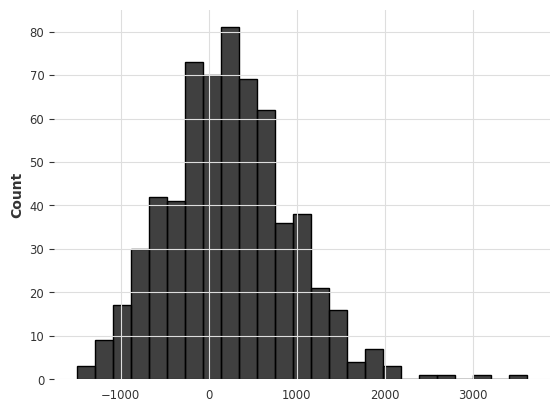

In [31]:
sns.histplot(lin_terms);

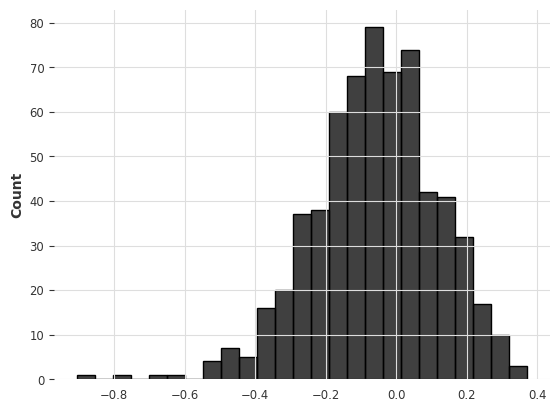

In [32]:
sns.histplot(quad_terms);

In [33]:
# Print the last model as an example

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.031
Date:                Mon, 12 May 2025   Prob (F-statistic):              0.384
Time:                        11:25:24   Log-Likelihood:                -54.781
No. Observations:                  16   AIC:                             115.6
Df Residuals:                      13   BIC:                             117.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.968e+05   4.29e+05      1.390      0.1

/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


#### ... and then cluster with K-means on linear and quadratic terms

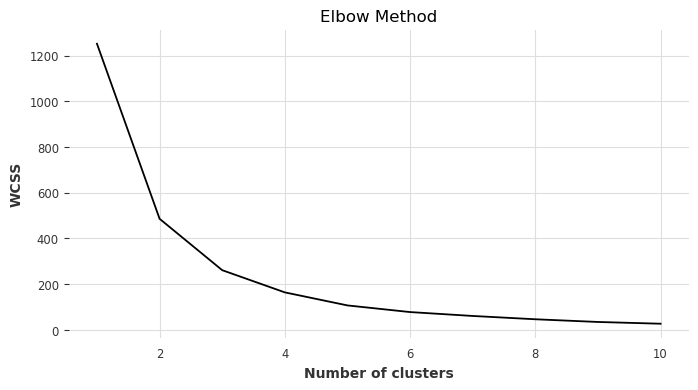

In [34]:
X = np.array([lin_terms, quad_terms]).T

# Normalize by column, unit variance, zero mean
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Perform elbow method to find optimal number of clusters
# wcss == within cluster sum of squares
wcss = []
max_clusters = 10 
for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, max_clusters + 1), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

We see that there is an elbow at around 2 clusters.

In [35]:
# 2D histogram could be plotted
# plt.hist2d(X[:,0], X[:,1], cmap='viridis');

#### 2 clusters look OK, we could use this quadratic model for clustering...

In [36]:
kmeans = KMeans(n_clusters=2, random_state=42) 
clusters = kmeans.fit_predict(X)

# Map clusters back to keys (station_id, bin)
cluster_results = pd.DataFrame({'key': keys, 'cluster': clusters})

print(cluster_results)

                        key  cluster
0    (1015_1, (1976, 1992])        0
1    (1034_1, (1960, 1976])        0
2    (1035_1, (1960, 1976])        0
3    (1039_1, (1976, 1992])        0
4    (1040_1, (1976, 1992])        0
..                      ...      ...
621   (983_1, (1960, 1976])        1
622   (992_1, (1960, 1976])        1
623   (992_1, (1976, 1992])        0
624   (993_1, (1976, 1992])        0
625   (998_1, (1976, 1992])        0

[626 rows x 2 columns]


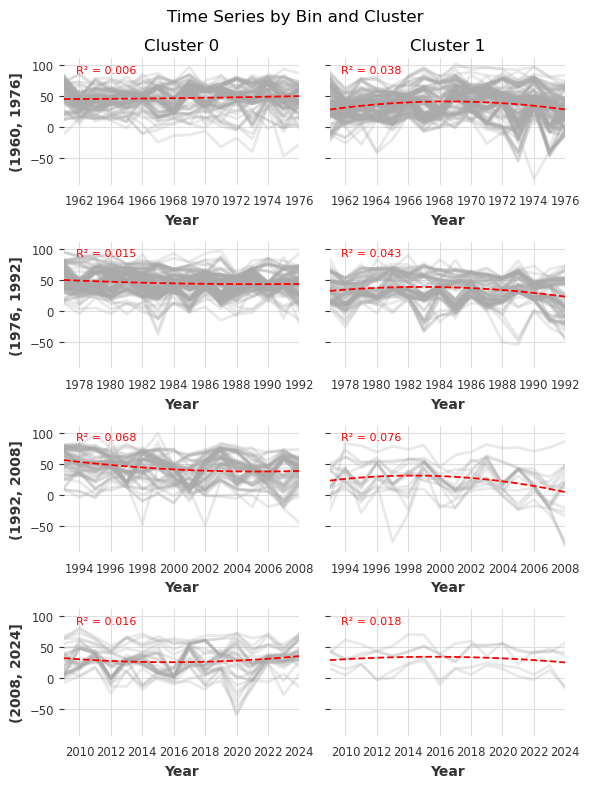

In [37]:
import warnings
warnings.filterwarnings('ignore')

# Get unique bins and clusters
unique_bins = sorted(set(key[1] for key in time_series_dict.keys()))
unique_clusters = sorted(cluster_results['cluster'].unique())

# Set up the plot grid
n_rows = len(unique_bins)
n_cols = len(unique_clusters)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), sharex=False, sharey=True)
fig.suptitle("Time Series by Bin and Cluster", fontsize=12)

# Plot time series for each bin and cluster
for (row, bin_label), (col, cluster) in product(enumerate(unique_bins), enumerate(unique_clusters)):
    ax = axes[row, col]
    
    # Filter time series for this bin and cluster
    cluster_keys = cluster_results[(cluster_results['cluster'] == cluster) & 
                                   (cluster_results['key'].apply(lambda x: x[1] == bin_label))]['key']
    
    all_x = []
    all_y = []
    
    for i, key in enumerate(cluster_keys):
        ts = time_series_dict[key]
        ts.plot(ax=ax, label=None, color="#aaaaaa", alpha=0.25)
        
        # Collect all x and y values for linear regression
        all_x.extend(ts.time_index.values)
        all_y.extend(ts.values().flatten())
    
    # Perform regression if we have data
    if all_x and all_y:

        data = pd.DataFrame({'x': all_x, 'y': all_y})
        model = smf.ols(formula='y ~ x + I(x**2)', data=data).fit()
        
        # Generate predictions for plotting
        x_pred = np.linspace(data['x'].min(), data['x'].max(), 100)
        data_pred = pd.DataFrame({'x': x_pred})
        data_pred['y_pred'] = model.predict(data_pred)

        r_squared = model.rsquared
        
        # Plot the OLS fit
        ax.plot(np.linspace(min(all_x), max(all_x), 100), 
                data_pred['y_pred'], color='red', linestyle='--')
        
        ax.text(0.05, 0.95, f'R² = {r_squared:.3f}', 
                transform=ax.transAxes, 
                verticalalignment='top', fontsize=8, color='red')
    
    # Set titles and labels
    if row == 0:
        ax.set_title(f"Cluster {cluster}")
    if col == 0:
        ax.set_ylabel(bin_label)
    
    ax.set_xlabel("Year")
    
    # Adjust x-axis to fill the panel
    if all_x:
        ax.set_xlim(min(all_x), max(all_x))
    
    # Remove legend
    ax.legend().remove()

    # Show integer x
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Adjust layout and display
plt.tight_layout()
plt.show()


#### But simple slope (no quadratic term) might be easier

In [38]:
slopes = []
keys = []

for key, ts in time_series_dict.items():
    keys.append(key)

    x = ts.time_index.values
    y = ts.values().flatten()

    data = pd.DataFrame({'x': x, 'y': y})
    model = smf.ols(formula='y ~ x', data=data).fit()
    linear_term = model.params['x']
    # quadratic_term = model.params['I(x ** 2)']

    slopes.append(linear_term)

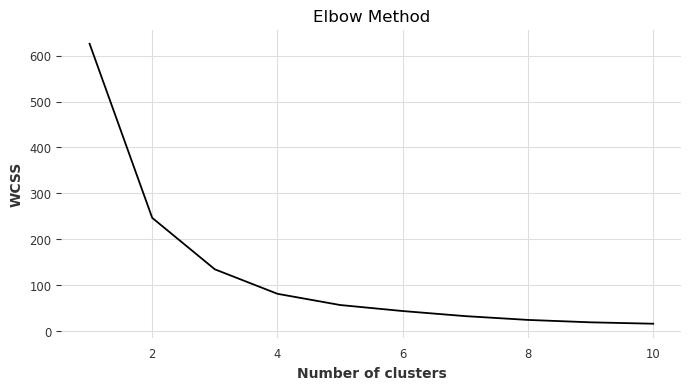

In [39]:
X = np.array(slopes).reshape(-1, 1)

# Normalize by column, unit variance, zero mean
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Perform elbow method to find optimal number of clusters
# wcss == within cluster sum of squares
wcss = []
max_clusters = 10 
for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, max_clusters + 1), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [40]:
kmeans = KMeans(n_clusters=2, random_state=42) 
clusters = kmeans.fit_predict(X)

# Map clusters back to keys (station_id, bin)
cluster_results = pd.DataFrame({'key': keys, 'cluster': clusters})

print(cluster_results)

                        key  cluster
0    (1015_1, (1976, 1992])        0
1    (1034_1, (1960, 1976])        0
2    (1035_1, (1960, 1976])        0
3    (1039_1, (1976, 1992])        0
4    (1040_1, (1976, 1992])        0
..                      ...      ...
621   (983_1, (1960, 1976])        0
622   (992_1, (1960, 1976])        0
623   (992_1, (1976, 1992])        0
624   (993_1, (1976, 1992])        0
625   (998_1, (1976, 1992])        0

[626 rows x 2 columns]


<Axes: xlabel='slope', ylabel='Count'>

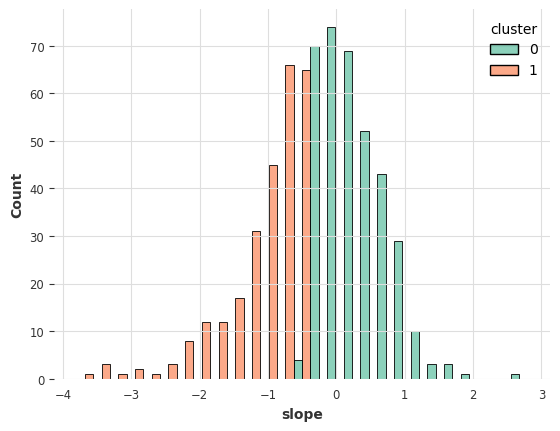

In [41]:
_df = pd.DataFrame({'slope': slopes, 'cluster': cluster_results['cluster']})

sns.histplot(data=_df, x='slope', hue='cluster', multiple='dodge', palette='Set2')

#### It seems like the clusters will be divided by slope around 0. To increase interpretability, let's just set the "cluster" manually.

In [42]:
clusters = np.where(np.array(slopes) > 0, 1, 0)

# Map clusters back to keys (station_id, bin)
cluster_results = pd.DataFrame({'key': keys, 'cluster': clusters})

print(cluster_results)

                        key  cluster
0    (1015_1, (1976, 1992])        1
1    (1034_1, (1960, 1976])        0
2    (1035_1, (1960, 1976])        1
3    (1039_1, (1976, 1992])        1
4    (1040_1, (1976, 1992])        1
..                      ...      ...
621   (983_1, (1960, 1976])        0
622   (992_1, (1960, 1976])        1
623   (992_1, (1976, 1992])        1
624   (993_1, (1976, 1992])        1
625   (998_1, (1976, 1992])        1

[626 rows x 2 columns]


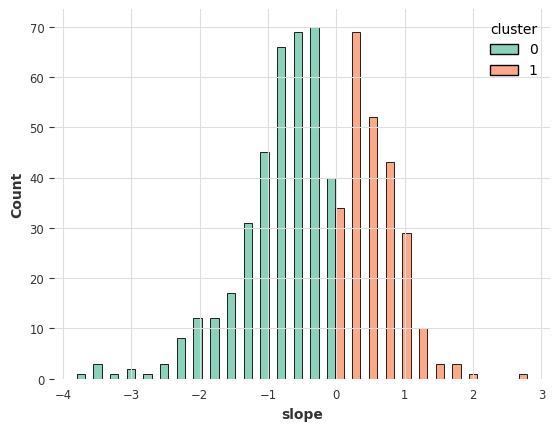

In [43]:
_df = pd.DataFrame({'slope': slopes, 'cluster': cluster_results['cluster']})

sns.histplot(data=_df, x='slope', hue='cluster', multiple='dodge', palette='Set2')
plt.savefig('../Images/slope-cluster-distr.png', dpi=600)

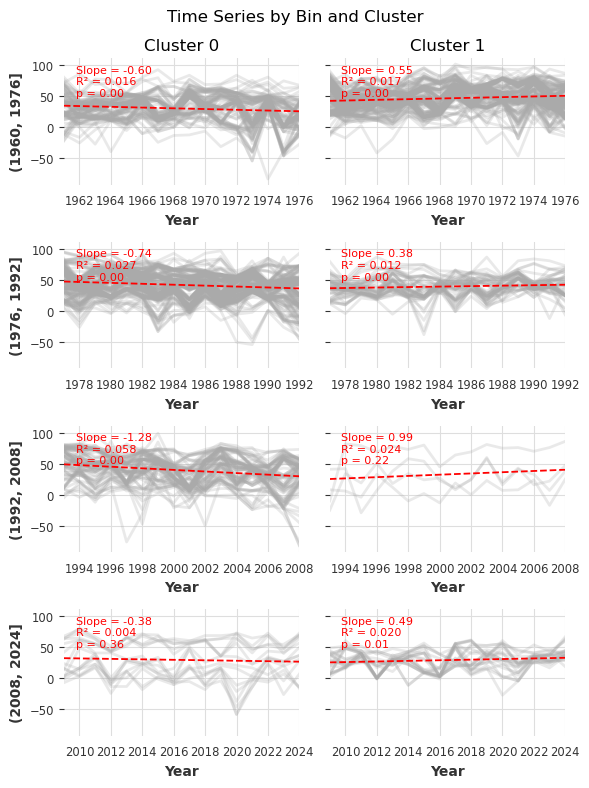

In [44]:
import warnings
warnings.filterwarnings('ignore')

# Get unique bins and clusters
unique_bins = sorted(set(key[1] for key in time_series_dict.keys()))
unique_clusters = sorted(cluster_results['cluster'].unique())

# Set up the plot grid
n_rows = len(unique_bins)
n_cols = len(unique_clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), sharex=False, sharey=True)
fig.suptitle("Time Series by Bin and Cluster", fontsize=12)

# Plot time series for each bin and cluster
for (row, bin_label), (col, cluster) in product(enumerate(unique_bins), enumerate(unique_clusters)):
    ax = axes[row, col]
    
    # Filter time series for this bin and cluster
    cluster_keys = cluster_results[(cluster_results['cluster'] == cluster) & 
                                   (cluster_results['key'].apply(lambda x: x[1] == bin_label))]['key']
    
    all_x = []
    all_y = []
    
    for i, key in enumerate(cluster_keys):
        ts = time_series_dict[key]
        ts.plot(ax=ax, label=None, color="#aaaaaa", alpha=0.25)
        
        # Collect all x and y values for linear regression
        all_x.extend(ts.time_index.values)
        all_y.extend(ts.values().flatten())
    
    # Perform linear regression if we have data
    if all_x and all_y:
        slope, intercept, r_value, p_value, _ = stats.linregress(all_x, all_y)
        r_squared = r_value**2
        
        # Plot the linear fit
        x_range = np.array([min(all_x), max(all_x)])
        ax.plot(x_range, slope * x_range + intercept, color='red', linestyle='--')
        
        # Add R-squared value to the plot
        ax.text(0.05, 0.95, f'Slope = {slope:.2f}\nR² = {r_squared:.3f}\np = {p_value:.2f}', 
                transform=ax.transAxes, 
                verticalalignment='top', fontsize=8, color='red')
    
    # Set titles and labels
    if row == 0:
        ax.set_title(f"Cluster {cluster}")
    if col == 0:
        ax.set_ylabel(bin_label)
    
    ax.set_xlabel("Year")
    
    # Adjust x-axis to fill the panel
    if all_x:
        ax.set_xlim(min(all_x), max(all_x))
    
    # Remove legend
    ax.legend().remove()

    # Show integer x
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Adjust layout and display
plt.tight_layout()
plt.savefig('../Images/ts-by-bin-cluster.png', dpi=600)
plt.show()


### Continue with data preparation for model input

In [45]:
# Make a df with with cluster id
dfs = []

for bin_label, cluster in product(unique_bins, unique_clusters):
    cluster_keys = cluster_results[(cluster_results['cluster'] == cluster) & 
                                   (cluster_results['key'].apply(lambda x: x[1] == bin_label))]['key']

    for key in cluster_keys:
        ts = time_series_dict[key]
        _df = ts.pd_dataframe().reset_index()[['year', 'distance_to_jan_1']]
        _df['cluster'] = cluster
        _df['station_id'] = key[0]
        dfs.append(_df)

df_clustered = pd.concat(dfs)
df_clustered

component,year,distance_to_jan_1,cluster,station_id
0,1961,39.0,0,1034_1
1,1962,39.0,0,1034_1
2,1963,38.0,0,1034_1
3,1964,35.0,0,1034_1
4,1965,37.0,0,1034_1
...,...,...,...,...
11,2020,0.0,1,723_1
12,2021,10.0,1,723_1
13,2022,35.0,1,723_1
14,2023,37.0,1,723_1


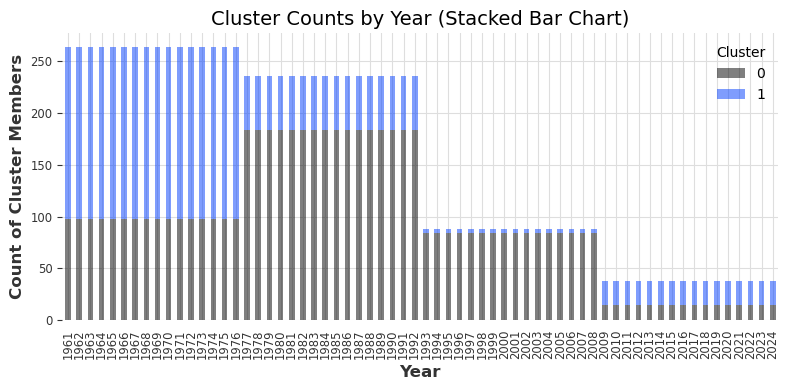

In [46]:
# Count occurrences of clusters per year
df_counts = df_clustered.groupby(['year', 'cluster']).size().unstack(fill_value=0)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(8, 4))
df_counts.plot(kind='bar', stacked=True, ax=ax, zorder=3, alpha=0.5)

ax.set_title('Cluster Counts by Year (Stacked Bar Chart)', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Count of Cluster Members', fontsize=12)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('../Images/clusters-count-by-year.png', dpi=600)
plt.show()


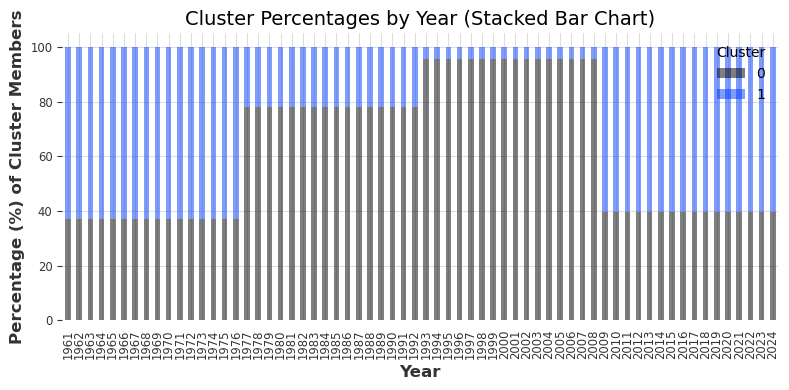

In [47]:
# Normalize counts to percentages (divide by row sums)
percentages = df_counts.div(df_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(8, 4))
percentages.plot(kind='bar', stacked=True, ax=ax, zorder=3, alpha=0.5)

ax.set_title('Cluster Percentages by Year (Stacked Bar Chart)', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percentage (%) of Cluster Members', fontsize=12)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('../Images/clusters-count-by-year-relative.png', dpi=600)
plt.show()

Especially for the third bin there is uneven distribution between clusters.

## Combine with ERA5 and lake data

In [48]:
ice_era = ice.merge(era, on=['station_id', 'year'], how='left')
ice_era_stats = ice_era.merge(lakes, on=['station_id'])

del ice_era
del era

In [49]:
ice_era_stats = ice_era_stats.merge(df_clustered, on=['year', 'station_id', 'distance_to_jan_1'])
ice_era_stats['cluster'].unique()

array([0, 1])

In [50]:
# log10 transform area
ice_era_stats['area_ha'] = np.log10(ice_era_stats['area_ha'])

In [51]:
ice_era_stats.dtypes

station_id                   object
year                          int64
ice_on               datetime64[ns]
ice_off              datetime64[ns]
bin                        category
distance_to_jan_1             int64
date                 datetime64[ns]
tair                        float64
tp                          float64
sf                          float64
month                         int32
lake_id                       int32
country                      object
subset                       object
lake_name                    object
lat_wgs84                   float64
lon_wgs84                   float64
altitude_m                  float64
area_ha                     float64
depth_mean_m                float64
depth_max_m                 float64
cent_lat_wgs84              float64
cent_lon_wgs84              float64
cluster                       int64
dtype: object

In [52]:
# Select columns for modeling

ice_era_stats = ice_era_stats[[
    'station_id', # 'year', 
    'distance_to_jan_1', 'date',
    'tair', 'tp', 'sf', # dynamic
    'bin',
    'lat_wgs84', 'altitude_m', 'area_ha', 'depth_mean_m', 'depth_max_m', # statics
    'cluster']]

#### Prepare data for featurization

In [53]:
ice_era_stats_long = pd.melt(ice_era_stats,
        # id_vars=['station_id', 'year'],
        id_vars=['station_id', 'date'],
        value_vars=[#'distance_to_jan_1', 
                    'tair', 'tp', 'sf',
                    # 'lat_wgs84', 'altitude_m', 'area_ha', 'cluster'
        ],
        var_name='kind',
        value_name='value')

In [54]:
ice_era_stats_long

,station_id,date,kind,value
0,1034_1,1961-01-01,tair,240.000687
1,1034_1,1961-01-02,tair,241.599808
2,1034_1,1961-01-03,tair,249.894897
3,1034_1,1961-01-04,tair,251.922150
4,1034_1,1961-01-05,tair,255.453842
...,...,...,...,...
10954051,726_1,2024-06-26,sf,0.000000
10954052,726_1,2024-06-27,sf,0.000000
10954053,726_1,2024-06-28,sf,0.000000
10954054,726_1,2024-06-29,sf,0.000000


In [55]:
len(ice_era_stats_long['station_id'].unique())

403

In [56]:
# Create id with station_id and year. This will be used for time feature generation.

ice_era_stats_long['id'] = (ice_era_stats_long['station_id'] + '__' + 
                            ice_era_stats_long['date'].dt.year.map(lambda x: str(x)))
ice_era_stats_long

,station_id,date,kind,value,id
0,1034_1,1961-01-01,tair,240.000687,1034_1__1961
1,1034_1,1961-01-02,tair,241.599808,1034_1__1961
2,1034_1,1961-01-03,tair,249.894897,1034_1__1961
3,1034_1,1961-01-04,tair,251.922150,1034_1__1961
4,1034_1,1961-01-05,tair,255.453842,1034_1__1961
...,...,...,...,...,...
10954051,726_1,2024-06-26,sf,0.000000,726_1__2024
10954052,726_1,2024-06-27,sf,0.000000,726_1__2024
10954053,726_1,2024-06-28,sf,0.000000,726_1__2024
10954054,726_1,2024-06-29,sf,0.000000,726_1__2024


In [57]:
# Define feature extraction parameters.
# For full feature list, see https://tsfresh.readthedocs.io/en/latest/text/list_of_features.html

custom_fc_parameters = {
    "mean": None,
    "minimum": None,
    "maximum": None,
    "variance": None,
    # "standard_deviation": None,
    # "linear_trend": [{"attr": "slope"}],  # positive control
    # "linear_trend": [{"attr": "slope"}, {"attr": "intercept"}],
    # Second-order trend (acceleration) via aggregated chunks
    # "agg_linear_trend": [
    #     {"attr": "slope", "chunk_len": 10, "f_agg": "mean"},
    #     {"attr": "slope", "chunk_len": 20, "f_agg": "mean"}
    # ],
    "number_peaks": [{"n": 7}],            # peak with support of 7 (days)
    "autocorrelation": [{"lag": 1}],      # kind of like lag
    "skewness": None,
    "kurtosis": None,
    "longest_strike_above_mean": None,
    "longest_strike_below_mean": None,
    "time_reversal_asymmetry_statistic": [{"lag": 7}]
}


## IF RUNNING WITH YEAR

def features_by_group(group):
    print(f'{ group["station_id"].iloc[0] }')
    features = extract_features(group,
                                column_id="station_id",
                                column_sort="yq",
                                column_kind="kind",
                                column_value="value",
                                default_fc_parameters=custom_fc_parameters,
                                disable_progressbar=True)
    return features

#ice_era_feats = ice_era_stats_long.groupby(['id']).apply(lambda group: features_by_group(group))

## OTHERWISE

ice_era_feats = extract_features(ice_era_stats_long,
                                 column_id="id",
                                 column_sort="date",
                                 column_kind="kind",
                                 column_value="value",
                                 default_fc_parameters=custom_fc_parameters,
                                 disable_progressbar=False)

Feature Extraction: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:09<00:00,  6.23it/s]


In [58]:
# ice_era_feats.dtypes

In [59]:
# extract station_id and year
ice_era_feats['station_id'] = ice_era_feats.index.str.split('__').map(lambda x: x[0])
ice_era_feats['year'] = ice_era_feats.index.str.split('__').map(lambda x: x[1])

#### Further data processing

In [60]:
# Get the static data
df = (ice_era_stats.groupby(['station_id']).first()[['lat_wgs84', 'altitude_m',  'area_ha', 'depth_mean_m', 'depth_max_m', 
                                                     'cluster', 'bin']].
      merge(ice_era_feats, on='station_id'))

df['bin'], unique_values = pd.factorize(df['bin'])
df['year'] = df['year'].astype('int')

df.dtypes

station_id                                         object
lat_wgs84                                         float64
altitude_m                                        float64
area_ha                                           float64
depth_mean_m                                      float64
depth_max_m                                       float64
cluster                                             int64
bin                                                 int64
sf__mean                                          float64
sf__minimum                                       float64
sf__maximum                                       float64
sf__variance                                      float64
sf__number_peaks__n_7                             float64
sf__autocorrelation__lag_1                        float64
sf__skewness                                      float64
sf__kurtosis                                      float64
sf__longest_strike_above_mean                     float64
sf__longest_st

In [61]:
# Let's remove some collinear ones to help variable interpretation later on.

# These we don't remove.
keep_variables = {'station_id', 'lat_wgs84', 'altitude_m', 'area_h', 'depth_max_m', 'cluster', 'bin'}

threshold = 0.9

# Compute correlation matrix
corr_matrix = df.corr().abs()

# Identify pairs of highly correlated features
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features to drop based on collinearity
to_drop = set()
for column in upper_triangle.columns:
    for index in upper_triangle.index:
        if upper_triangle.loc[index, column] > threshold:
            # Drop the feature unless it's in the keep set
            if column not in keep_variables:
                to_drop.add(column)
            elif index not in keep_variables:
                to_drop.add(index)

# Drop collinear features from the DataFrame
df_cleaned = df.drop(columns=to_drop)
# df_cleaned

In [62]:
df = df_cleaned

## Model fitting

In [63]:
# Group by station_id and get unique station IDs with their majority class label
station_labels = df.groupby('station_id')['cluster'].agg(lambda x: x.mode()[0]).reset_index()
station_ids = station_labels['station_id']
station_classes = station_labels['cluster']

# Stratified split for train-test based on station labels
train_stations, test_stations = train_test_split(
    station_ids,
    test_size=0.2,
    stratify=station_classes,
    random_state=11
)

# Further split train stations into train-val sets
train_stations_final, val_stations = train_test_split(
    train_stations,
    test_size=0.25,
    stratify=station_classes[station_classes.index.isin(train_stations.index)],
    random_state=11
)

# Create train/val/test datasets based on station IDs
train_data = df[df['station_id'].isin(train_stations_final)]
val_data = df[df['station_id'].isin(val_stations)]
test_data = df[df['station_id'].isin(test_stations)]

# Sort
train_data = train_data.sort_values(by=['station_id', 'year'])
val_data = val_data.sort_values(by=['station_id', 'year'])
test_data = test_data.sort_values(by=['station_id', 'year'])

print("Train Data Class Distribution:")
print(train_data['cluster'].value_counts())

print("\nValidationData Class Distribution:")
print(val_data['cluster'].value_counts())

print("\nTest Data Class Distribution:")
print(test_data['cluster'].value_counts())

Train Data Class Distribution:
cluster
0    3072
1    2784
Name: count, dtype: int64

ValidationData Class Distribution:
cluster
1    1152
0     896
Name: count, dtype: int64

Test Data Class Distribution:
cluster
0    1072
1    1040
Name: count, dtype: int64


In [64]:
# We could remove the bin information.
# X_train = train_data.drop(columns=['station_id', 'cluster', 'bin'])
# X_val = val_data.drop(columns=['station_id', 'cluster', 'bin'])
# X_test = test_data.drop(columns=['station_id', 'cluster', 'bin'])

X_train = train_data.drop(columns=['station_id', 'cluster'])
X_val = val_data.drop(columns=['station_id', 'cluster'])
X_test = test_data.drop(columns=['station_id', 'cluster'])

y_train = train_data[['cluster']]
y_val = val_data[['cluster']]
y_test = test_data[['cluster']]

# Data scaling.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [65]:
y_train['cluster'].unique()

array([1, 0])

### Use optuna to tune hyperparameters on validation set

In [66]:
# Define the objective function for Optuna
def objective(trial):
    
    # Define the hyperparameter search space
    param = {
        'objective': 'binary',  # two classes
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        #'num_leaves': trial.suggest_int('num_leaves', 2, 512),
        'num_leaves': trial.suggest_int('num_leaves', 2, 30),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0), # 0.1
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0), # 0.4
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 12),
        # 'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),  # 500
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),  # 500
        #'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'seed': 123
    }
    
    # Create LightGBM datasets
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_val, label=y_val)
    
    # Train the model using the current hyperparameters
    gbm = lgb.train(param, dtrain, valid_sets=[dval])
    
    # Predict and evaluate accuracy manually ...
    # preds = gbm.predict(X_val)
    # pred_labels = (preds > 0.5).astype(int)
    # accuracy = accuracy_score(y_val, pred_labels)
    # f1 = f1_score(y_val, pred_labels)
    
    # ... or use optuna stats
    return gbm.best_score['valid_0']['binary_logloss']

# Create an Optuna study and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)

# Print the best hyperparameters and score
print("Best hyperparameters:", study.best_params)
print("Best score:", study.best_value)

[I 2025-05-12 11:26:00,728] A new study created in memory with name: no-name-6676f1fa-a5f0-4019-96c5-14a22ddbcb55
[I 2025-05-12 11:26:00,756] Trial 0 finished with value: 0.5790911376782022 and parameters: {'lambda_l1': 7.827705434282505e-06, 'lambda_l2': 8.529268848387671e-07, 'num_leaves': 4, 'feature_fraction': 0.9401986770758404, 'bagging_fraction': 0.6576883159021516, 'bagging_freq': 7, 'min_child_samples': 30, 'learning_rate': 0.04567685598224282}. Best is trial 0 with value: 0.5790911376782022.
[I 2025-05-12 11:26:00,780] Trial 1 finished with value: 0.6772191785764455 and parameters: {'lambda_l1': 0.00010597414382901396, 'lambda_l2': 6.679016883956861e-07, 'num_leaves': 2, 'feature_fraction': 0.9606016012518139, 'bagging_fraction': 0.7349332506187116, 'bagging_freq': 1, 'min_child_samples': 13, 'learning_rate': 0.003768378812714536}. Best is trial 0 with value: 0.5790911376782022.
[I 2025-05-12 11:26:00,829] Trial 2 finished with value: 0.6366361050357014 and parameters: {'lamb

Best hyperparameters: {'lambda_l1': 0.04988541178661813, 'lambda_l2': 1.9310870295740994e-05, 'num_leaves': 4, 'feature_fraction': 0.7650566796017598, 'bagging_fraction': 0.9848221065760533, 'bagging_freq': 3, 'min_child_samples': 19, 'learning_rate': 0.04528673122795698}
Best score: 0.5578022254558448


In [67]:
# We could plot optuna slice plot to see how hyperparameters influence the objective
# from plotly.io import show
# fig = optuna.visualization.plot_slice(study)
# show(fig)

In [68]:
best_params = dict({'seed': 123}, **study.best_params)
best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)

# Evaluation
y_pred = best_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred))

# Feature importance
feature_names = train_data.drop(columns=['station_id', 'cluster']).columns
importance = pd.Series(best_model.feature_importances_, 
                       index=feature_names)


print(importance.sort_values(ascending=False).head(10))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1072
           1       0.85      0.78      0.81      1040

    accuracy                           0.82      2112
   macro avg       0.82      0.82      0.82      2112
weighted avg       0.82      0.82      0.82      2112

bin               92
lat_wgs84         87
area_ha           35
depth_max_m       30
altitude_m        19
depth_mean_m      18
tair__mean        16
tair__variance     3
sf__maximum        0
sf__variance       0
dtype: int32


In [69]:
f1_score(y_test, (best_model.predict(X_test) > 0.5).astype(int))

0.8118118118118118

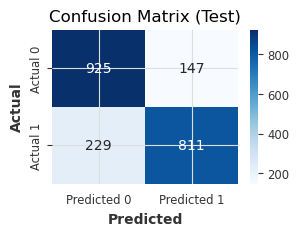

In [70]:
def plot_confusion(y_true, y_pred, title=None):
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot with annotations
    plt.figure(figsize=(3, 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    if not title:
        plt.title('Confusion Matrix')
    else:
        plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion(y_test, (best_model.predict(X_test) > 0.5).astype(int), "Confusion Matrix (Test)")

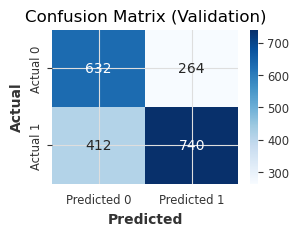

In [71]:
plot_confusion(y_val, (best_model.predict(X_val) > 0.5).astype(int), "Confusion Matrix (Validation)")

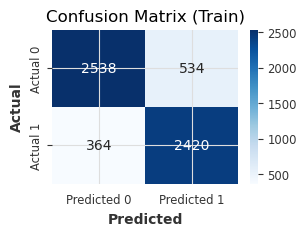

In [72]:
plot_confusion(y_train, (best_model.predict(X_train) > 0.5).astype(int), "Confusion Matrix (Train)")

### SHAP on test

In [73]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)
shap_values.feature_names = feature_names


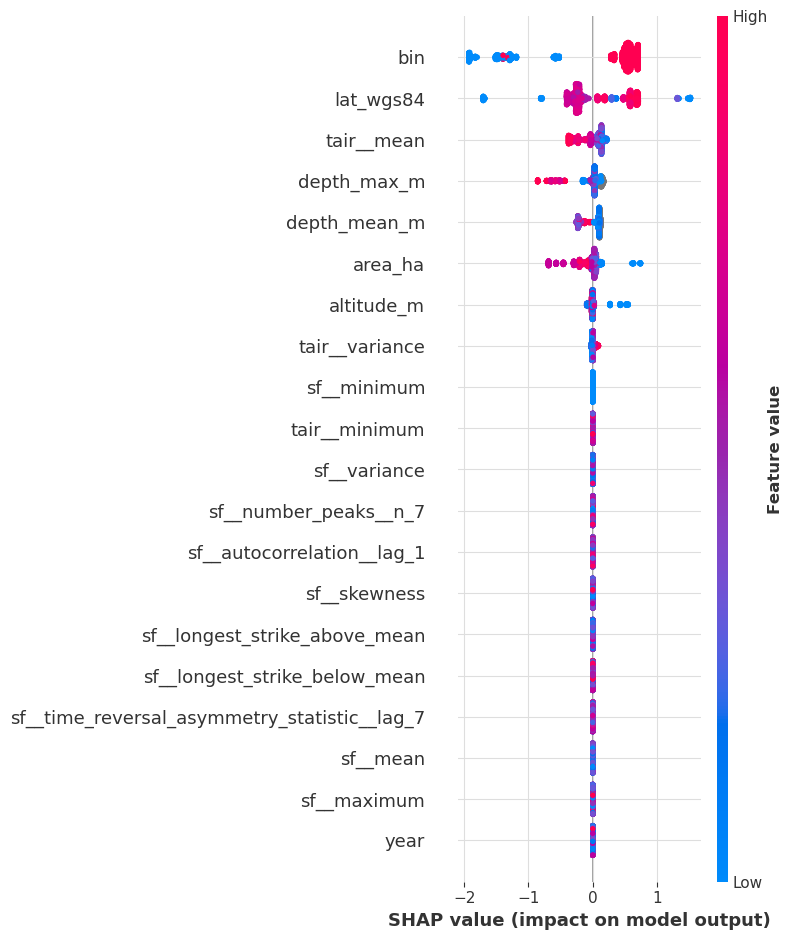

In [74]:
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../Images/shap-importance-test-set.png', dpi=600)

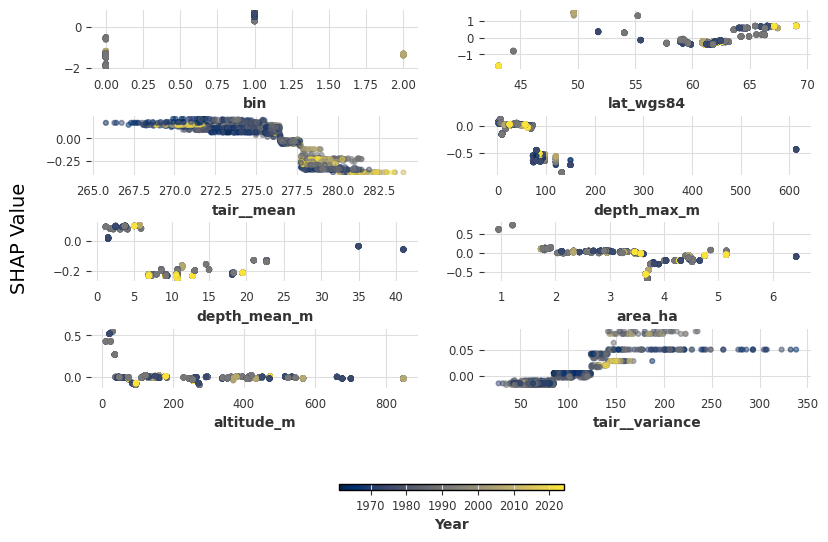

In [75]:
# Get feature importance based on mean absolute SHAP values
# feature_importance = np.abs(shap_values).mean(axis=0)
feature_importance = np.abs(shap_values.values).mean(axis=0)
top_features = np.argsort(feature_importance)[-8:][::-1]  # Indices of the most important features

# Data on original scale (rounded)
orig_data = np.round(scaler.inverse_transform(shap_values.data), 10)

# Color by year
focus_column = np.where(feature_names == 'year')[0]
cmap = plt.get_cmap('cividis')
norm = Normalize(vmin=np.min(orig_data[:, focus_column]),
                 vmax=np.max(orig_data[:, focus_column])) 

# Map years to colors using the colormap and normalization
color = cmap(norm(orig_data[:, focus_column]))

# Create a 3x2 panel for dependence plots
fig, axes = plt.subplots(4, 2, figsize=(9, 6), sharey=False) 

for i, feature_index in enumerate(top_features):
    row, col = divmod(i, 2) 
    ax = axes[row, col]
    
    # mask for NAs
    not_na = ~test_data[feature_names[feature_index]].isna().to_numpy()
    
    #shap.plots.scatter(shap_values[not_na, feature_index], 
    #                   ax=ax, show=False)

    _x = orig_data[not_na, feature_index]
    _y = shap_values[not_na, feature_index].values
    ax.scatter(_x, _y, alpha=0.5, s=12, color=color[not_na], zorder=3)
    
    # Subplot title
    ax.set_xlabel(f'{feature_names[feature_index]}')
    ax.set_ylabel('')

# Add unified legend below
sm = ScalarMappable(norm=norm, cmap='cividis')
# cbar_ax = fig.add_axes([0.375, -0.05, 0.25, 0.01])  # [left, bottom, width, height]
cbar_ax = fig.add_axes([0.375, 0.08, 0.25, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Year', fontsize=10)

# Set ticks for the colorbar
decades = np.arange(1970, 2021, 10)
cbar.set_ticks(decades)
cbar.set_ticklabels([f"{int(y)}" for y in decades])  # Force integer formatting

# Adjust layout to avoid overlapping titles/labels
# fig.text(-0.02, 0.5, 'SHAP Value', va='center', rotation='vertical', fontsize=14)
fig.text(0.01, 0.5, 'SHAP Value', va='center', rotation='vertical', fontsize=14)
# plt.tight_layout()

plt.subplots_adjust(left=0.10, bottom=0.25, hspace=0.8)
plt.savefig('../Images/shap-panel-test-set.png', dpi=600)
plt.show()

### SHAP on train

In [76]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_train)
shap_values.feature_names = feature_names

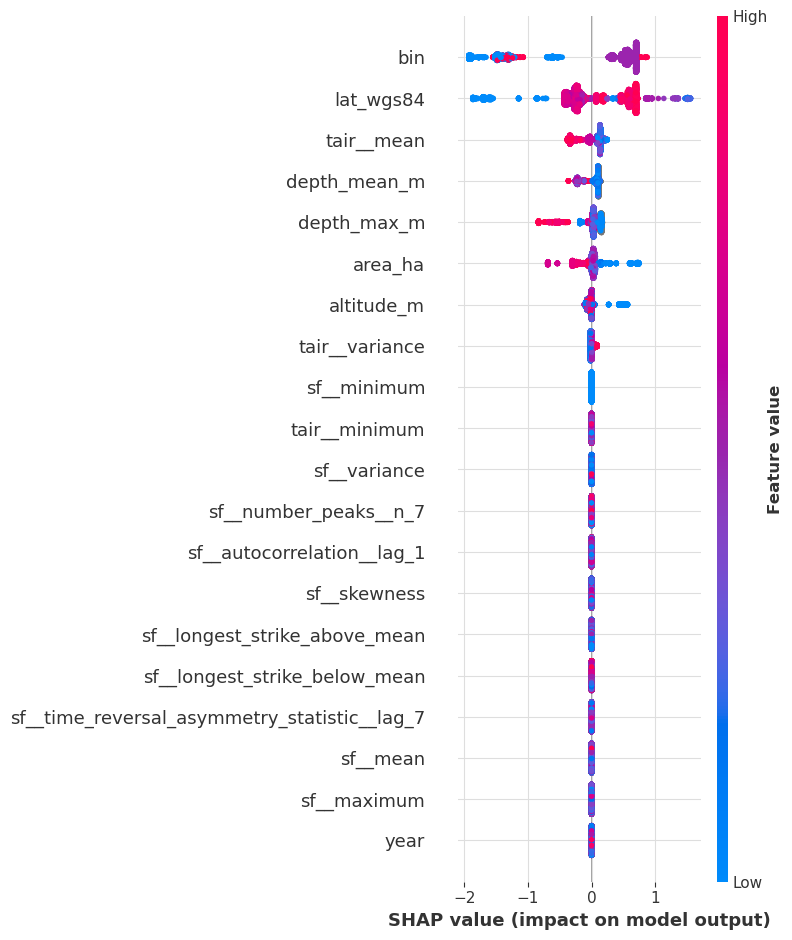

In [77]:
shap.summary_plot(shap_values, X_train, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../Images/shap-importance-training-set.png', dpi=600)

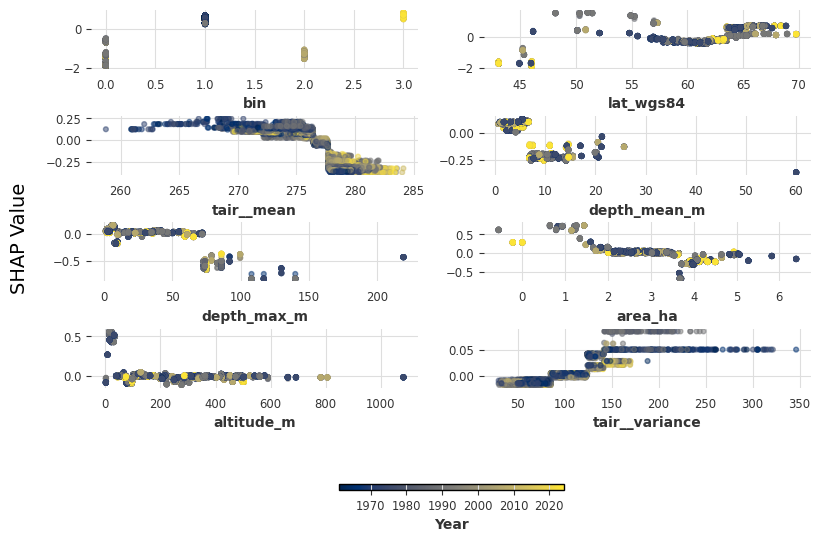

In [78]:
# Get feature importance based on mean absolute SHAP values
# feature_importance = np.abs(shap_values).mean(axis=0)
feature_importance = np.abs(shap_values.values).mean(axis=0)
top_features = np.argsort(feature_importance)[-8:][::-1]  # Indices of the most important features

# Data on original scale (rounded)
orig_data = np.round(scaler.inverse_transform(shap_values.data), 10)

# color by year
focus_column = np.where(feature_names == 'year')[0]
cmap = plt.get_cmap('cividis')
norm = Normalize(vmin=np.min(orig_data[:, focus_column]),
                 vmax=np.max(orig_data[:, focus_column])) 

# Map years to colors using the colormap and normalization
color = cmap(norm(orig_data[:, focus_column]))

# Create a 3x2 panel for dependence plots
fig, axes = plt.subplots(4, 2, figsize=(9, 6), sharey=False) 

for i, feature_index in enumerate(top_features):
    row, col = divmod(i, 2) 
    ax = axes[row, col]
    
    # mask for NAs
    not_na = ~train_data[feature_names[feature_index]].isna().to_numpy()
    
    #shap.plots.scatter(shap_values[not_na, feature_index], 
    #                   ax=ax, show=False)

    _x = orig_data[not_na, feature_index]
    _y = shap_values[not_na, feature_index].values
    ax.scatter(_x, _y, alpha=0.5, s=12, color=color[not_na], zorder=3)
    
    # Subplot title
    ax.set_xlabel(f'{feature_names[feature_index]}')
    ax.set_ylabel('')

# Adjust layout to avoid overlapping titles/labels
# fig.text(-0.02, 0.5, 'SHAP Value', va='center', rotation='vertical', fontsize=14)
fig.text(0.01, 0.5, 'SHAP Value', va='center', rotation='vertical', fontsize=14)


# Add unified legend below
sm = ScalarMappable(norm=norm, cmap='cividis')
# cbar_ax = fig.add_axes([0.375, -0.05, 0.25, 0.01])  # [left, bottom, width, height]
cbar_ax = fig.add_axes([0.375, 0.08, 0.25, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Year', fontsize=10)

# Set ticks for the colorbar
decades = np.arange(1970, 2021, 10)
cbar.set_ticks(decades)
cbar.set_ticklabels([f"{int(y)}" for y in decades])  # Force integer formatting

plt.subplots_adjust(left=0.10, bottom=0.25, hspace=0.8)
# plt.tight_layout()

plt.savefig('../Images/shap-panel-training-set.png', dpi=600)
plt.show()